# **Text Detection with DB**

## **Objectives:**
1. Detect lines of text in an image with `cv2.dnn_TextDetectionModel_DB` — built into stock OpenCV, no contrib module needed
2. See it handle genuinely rotated text as tilted quadrilaterals, not just axis-aligned boxes
3. Straighten one detected text region with the exact perspective-warp technique from notebook 18

> **Assets.** `assets/models/text_detection_en_ppocrv3_2023may.onnx` is PP-OCRv3's detector, from [opencv/opencv_zoo](https://github.com/opencv/opencv_zoo/tree/main/models/text_detection_ppocr) (Apache 2.0, 2.4MB). OpenCV's own `dnn_TextDetectionModel` also supports **EAST**, but the canonical EAST weights that OpenCV's own sample code points to are a Dropbox link and a Google Drive link — neither scriptably fetchable nor clearly licensed the way this repo's other assets have been — so this notebook uses **DB** (Differentiable Binarization) with the PP-OCRv3 weights instead, which has a clean, citable Apache-2.0 source. `assets/images/imageTextN.png` / `imageTextR.png` (upright and rotated real book-page text) are also OpenCV's own official samples.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **How DB finds text, intuitively**

**Differentiable Binarization** predicts a per-pixel *probability map* — "how likely is this pixel part of a text character?" — over the whole image in one forward pass. That map gets thresholded into a binary mask (`setBinaryThreshold`), and each connected blob in the mask becomes one detected text region. Text regions in the raw mask come out slightly *smaller* than the actual text (thresholding naturally shrinks blobs to their most-confident core), so DB "unclips" each region — expands it outward by a factor (`setUnclipRatio`) — to recover the true text boundary. Because each region is described by an arbitrary polygon rather than a fixed-aspect-ratio box, DB handles rotated and curved text naturally — there's no assumption anywhere that text runs horizontally.

## **Detecting upright text**

`cv2.dnn_TextDetectionModel_DB` wraps `cv2.dnn.readNet` with detection-specific pre/post-processing built in — set the input size, mean, and scale once, then `.detect()` returns a list of 4-point polygons directly, no manual grid decoding needed (unlike notebook 33's YOLOX, which is a generic detector doing none of that for you).

In [2]:
INPUT_SIZE = (736, 736)  # must be a multiple of 32

detector = cv2.dnn_TextDetectionModel_DB(cv2.dnn.readNet('assets/models/text_detection_en_ppocrv3_2023may.onnx'))
detector.setBinaryThreshold(0.3)
detector.setPolygonThreshold(0.5)
detector.setUnclipRatio(2.0)
detector.setMaxCandidates(200)
detector.setInputSize(INPUT_SIZE)
detector.setInputMean((123.675, 116.28, 103.53))
detector.setInputScale(1.0 / 255.0 / np.array([0.229, 0.224, 0.225]))

def detect_text(detector, image):
    h, w = image.shape[:2]
    resized = cv2.resize(image, INPUT_SIZE)
    boxes, confidences = detector.detect(resized)
    scale_x, scale_y = w / INPUT_SIZE[0], h / INPUT_SIZE[1]
    scaled_boxes = []
    for box in boxes:
        box = box.astype(np.float32)
        box[:, 0] *= scale_x
        box[:, 1] *= scale_y
        scaled_boxes.append(box)
    return scaled_boxes

def draw_boxes(image, boxes):
    vis = image.copy()
    for box in boxes:
        cv2.polylines(vis, [box.astype(np.int32)], True, (0, 255, 0), 2)
    return vis

13 text lines found


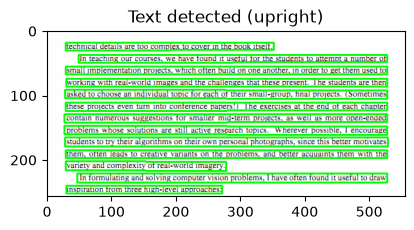

In [3]:
upright = cv2.imread('assets/images/imageTextN.png')
upright_boxes = detect_text(detector, upright)
print(f'{len(upright_boxes)} text lines found')
imshow('Text detected (upright)', draw_boxes(upright, upright_boxes))

## **The real test: rotated text**

`imageTextR.png` is the exact same paragraph, photographed/rendered at an angle. A method that only knew how to draw axis-aligned rectangles would either miss most of each line or grab huge overlapping boxes that half cover neighboring lines. Watch the boxes below tilt to match the text instead.

13 text lines found


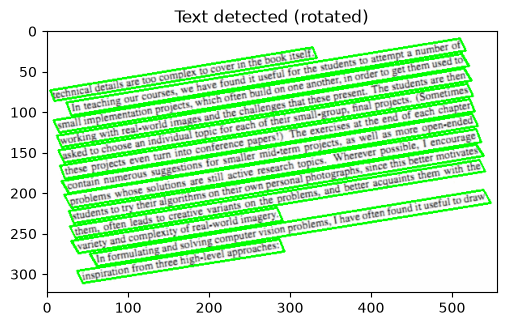

In [4]:
rotated = cv2.imread('assets/images/imageTextR.png')
rotated_boxes = detect_text(detector, rotated)
print(f'{len(rotated_boxes)} text lines found')
imshow('Text detected (rotated)', draw_boxes(rotated, rotated_boxes))

## **Straightening a detected line (notebook 18's technique)**

Detection gives you a quadrilateral, not a promise that it's rectangular or upright — exactly the situation notebook 18 solved for a photographed document: four corner points in, `cv2.getPerspectiveTransform` + `cv2.warpPerspective` out, and the region lands as a flat, horizontal rectangle.

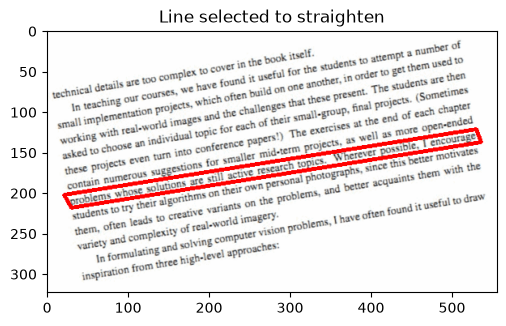

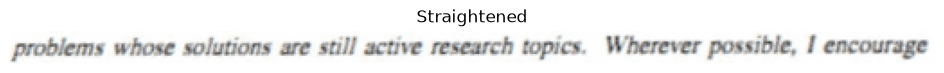

In [5]:
def order_points(pts):
    # top-left has the smallest x+y, bottom-right the largest;
    # top-right has the smallest x-y, bottom-left the largest
    s = pts.sum(axis=1)
    d = pts[:, 0] - pts[:, 1]
    return np.float32([
        pts[np.argmin(s)], pts[np.argmax(d)],
        pts[np.argmax(s)], pts[np.argmin(d)],
    ])

# pick the longest detected line (by polygon width) to straighten
target_box = max(rotated_boxes, key=lambda b: np.linalg.norm(b[0] - b[1]))
src_pts = order_points(target_box)

line_width = int(np.linalg.norm(src_pts[0] - src_pts[1]))
line_height = int(np.linalg.norm(src_pts[0] - src_pts[3]))
dst_pts = np.float32([[0, 0], [line_width, 0], [line_width, line_height], [0, line_height]])

M = cv2.getPerspectiveTransform(src_pts, dst_pts)
straightened = cv2.warpPerspective(rotated, M, (line_width, line_height))

highlighted = rotated.copy()
cv2.polylines(highlighted, [target_box.astype(np.int32)], True, (0, 0, 255), 3)
imshow('Line selected to straighten', highlighted)

# A single text line is extremely wide and short (~28:1 here) — imshow()'s
# figsize logic (tuned for roughly-square photos everywhere else in this
# repo) turns that into a tall, near-empty sliver, so this one output gets
# its own sensibly-proportioned figure instead.
plt.figure(figsize=(12, 12 * straightened.shape[0] / straightened.shape[1]))
plt.imshow(cv2.cvtColor(straightened, cv2.COLOR_BGR2RGB))
plt.title('Straightened')
plt.axis('off')
plt.show()

### A couple of things worth poking at

- Feed the straightened line crop into a CRNN/PaddleOCR *recognition* model (opencv_zoo doesn't currently ship one, but the DB detector's output is exactly the input a recognition step needs) to go from "where is text" to "what does it say."
- Lower `setBinaryThreshold` toward 0.1 on a low-contrast or blurry photo and watch recall improve at the cost of more false-positive boxes — the same precision/recall tradeoff notebook 13's blob detector and notebook 30's YuNet both exposed through their own thresholds.
- Run detection on `assets/images/scan.jpg` from notebook 18 — it's a synthetic warped page with no *real* text, a good check for whether DB is truly reading character shapes or just reacting to any high-contrast line pattern.